<a href="https://colab.research.google.com/github/Anshika-1209/waste-classification-system/blob/main/Copy_of_waste_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Anshika-1209/waste-classification-system.git

fatal: destination path 'waste-classification-system' already exists and is not an empty directory.


In [ ]:
!ls waste-classification-system

app  garbage_dataset  original_dataset	README.md  split_dataset.py


In [ ]:
!ls waste-classification-system/garbage_dataset

test  train  validation


In [ ]:
!ls waste-classification-system/garbage_dataset/train


cardboard  glass  metal  paper	plastic  trash


In [ ]:
import tensorflow as tf

train_dir = "/content/waste-classification-system/garbage_dataset/train"
val_dir = "/content/waste-classification-system/garbage_dataset/validation"
test_dir = "/content/waste-classification-system/garbage_dataset/test"

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.


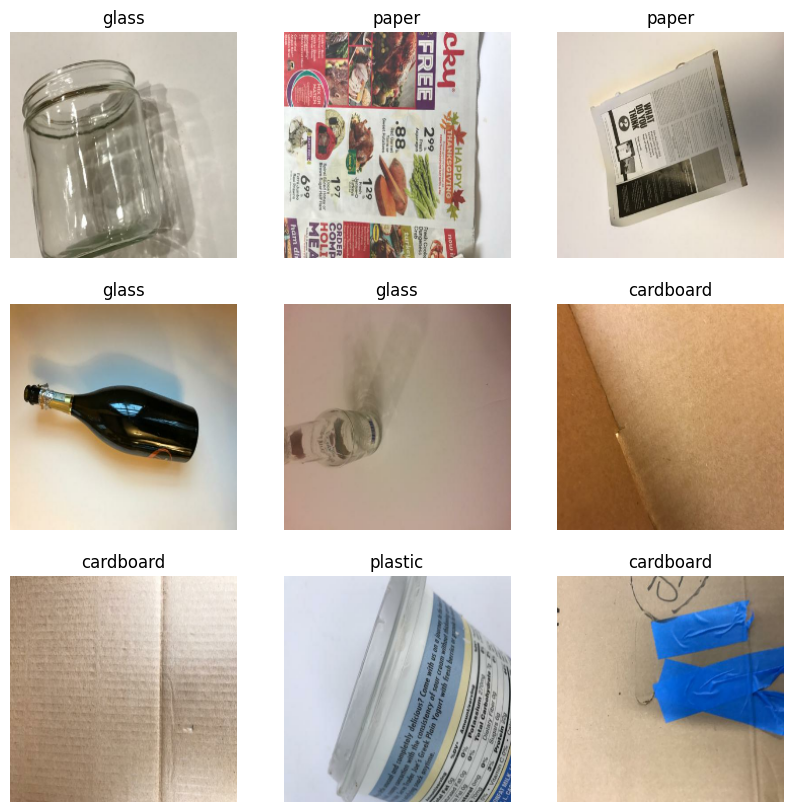

In [ ]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

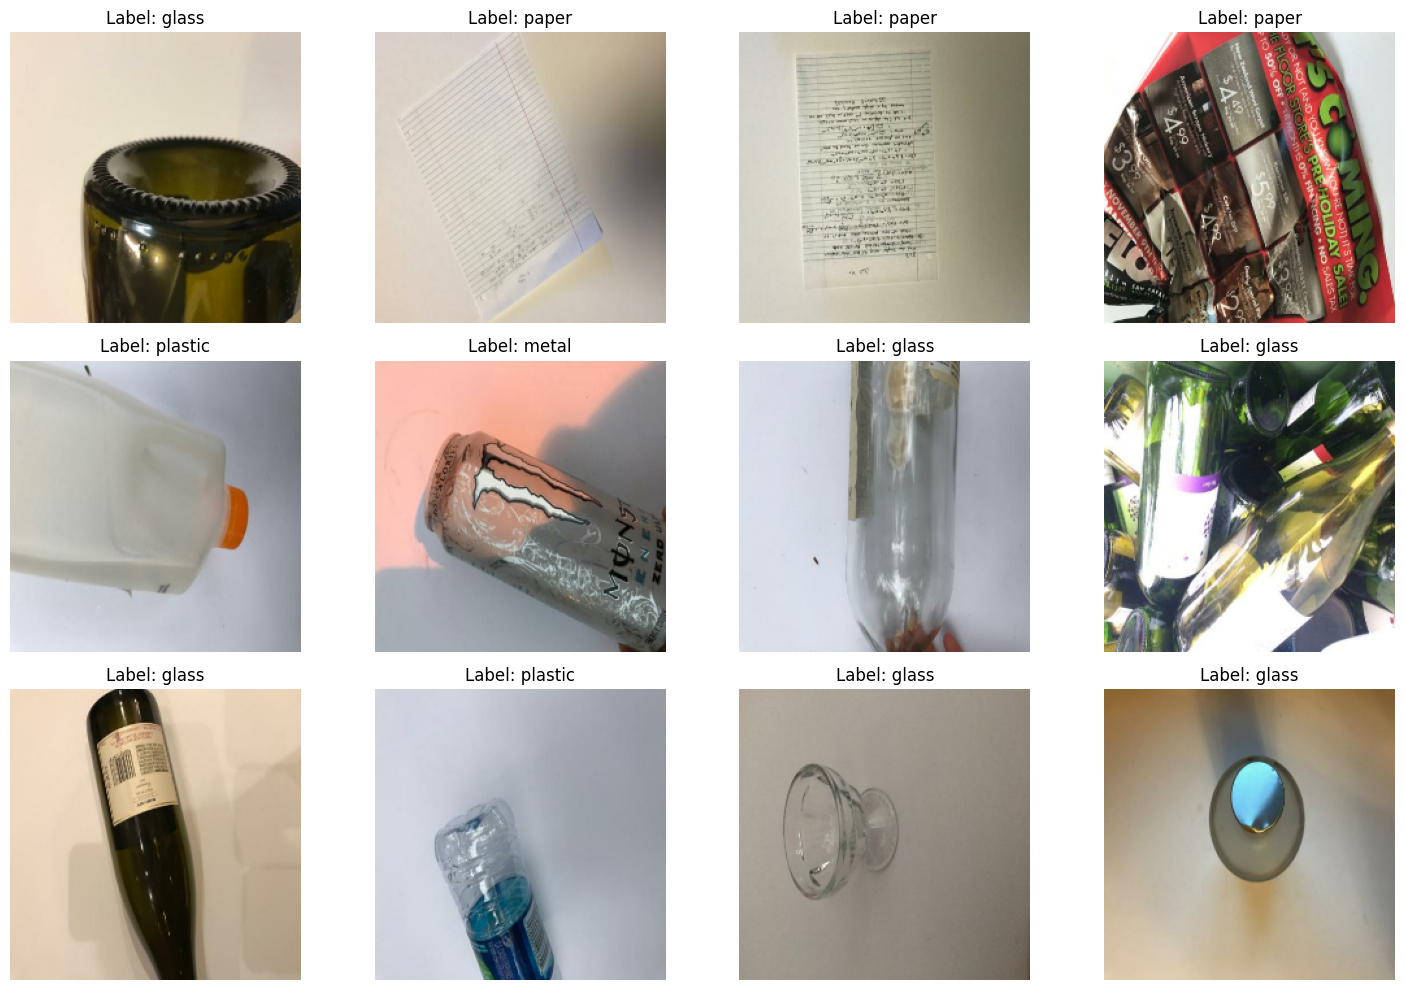

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

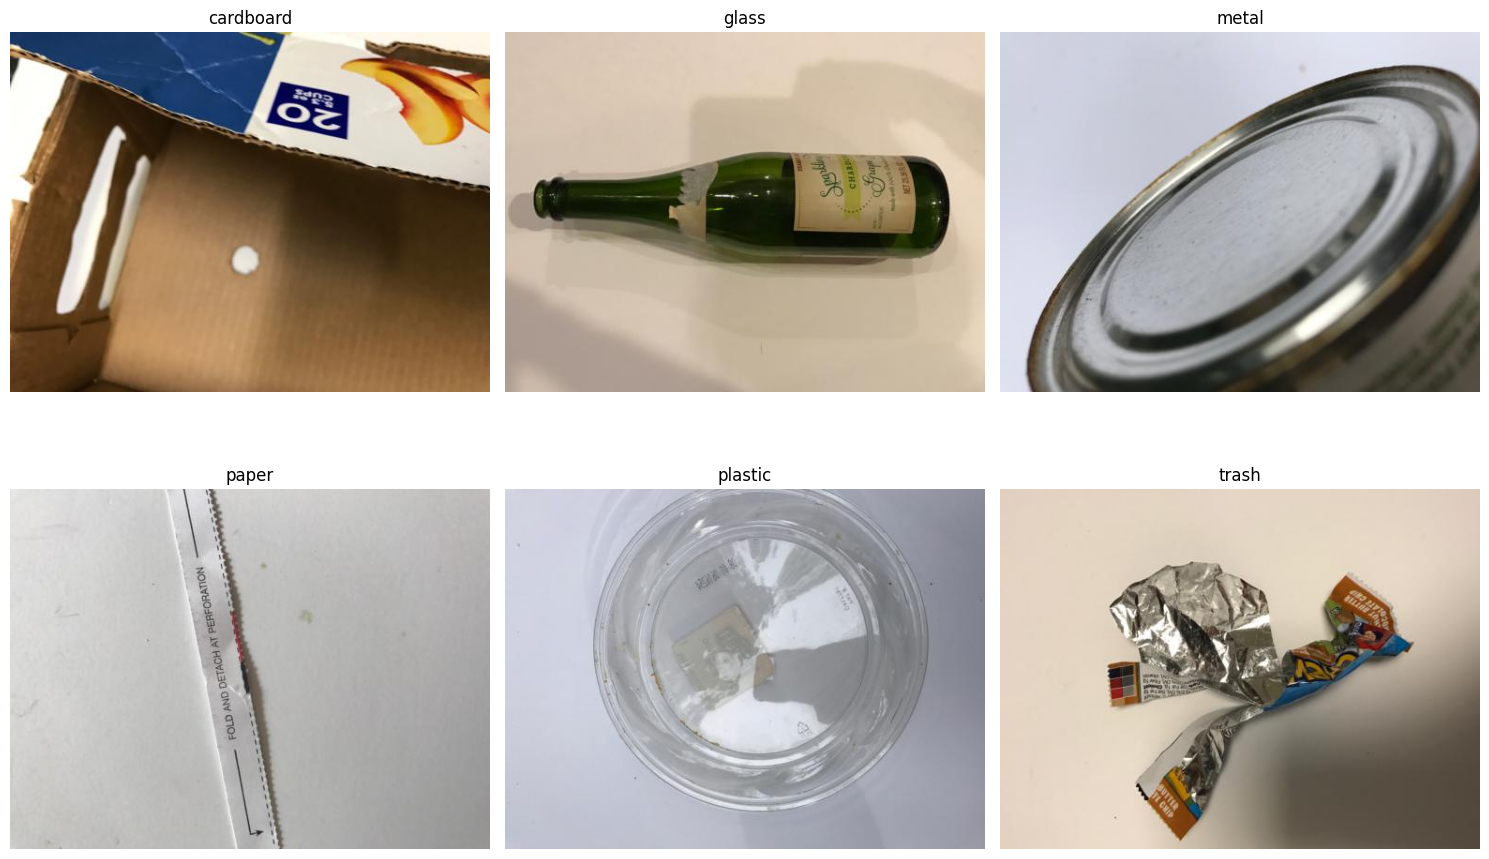

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

source_dir = "/content/waste-classification-system/original_dataset/Garbage classification"

classes = os.listdir(source_dir)

plt.figure(figsize=(15, 10))

plot_num = 1

for class_name in sorted(classes):

    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Choose one random image
    img_name = random.choice(images)

    img_path = os.path.join(class_path, img_name)

    image = Image.open(img_path)

    plt.subplot(2, 3, plot_num)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

    plot_num += 1

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(6, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(...)

ValueError: Unrecognized data type: x=Ellipsis (of type <class 'ellipsis'>)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.9377 - loss: 0.2103 - val_accuracy: 0.8966 - val_loss: 0.2997
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.9462 - loss: 0.2022 - val_accuracy: 0.8886 - val_loss: 0.2982
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.9496 - loss: 0.1856 - val_accuracy: 0.8966 - val_loss: 0.2926
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.9479 - loss: 0.1845 - val_accuracy: 0.8966 - val_loss: 0.2914
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.9592 - loss: 0.1685 - val_accuracy: 0.8939 - val_loss: 0.2876
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9621 - loss: 0.1622 - val_accuracy: 0.8939 - val_loss: 0.2835
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9575 - loss: 0.1559 - val_accuracy: 0.8939 - val_loss: 0.2808
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9626 - loss: 0.1509 - val_accuracy: 0.9019 - v

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8620 - loss: 0.3258
Test Accuracy: 0.8619791865348816
Test Loss: 0.3258349597454071


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get actual labels
y_true = np.concatenate([y.numpy() for x, y in test_ds])

# Get model predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Class Names:")
print(class_names)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step
Class Names:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Confusion Matrix:
[[57  0  0  4  0  0]
 [ 0 58 10  2  6  0]
 [ 0  2 59  0  1  0]
 [ 2  0  2 84  0  2]
 [ 0  9  0  2 59  3]
 [ 2  0  2  3  1 14]]

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.93      0.93      0.93        61
       glass       0.84      0.76      0.80        76
       metal       0.81      0.95      0.87        62
       paper       0.88      0.93      0.91        90
     plastic       0.88      0.81      0.84        73
       trash       0.74      0.64      0.68        22

    accuracy                           0.86       384
   macro avg       0.85      0.84      0.84       384
weighted avg       0.86      0.86      0.86       384



In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow.keras import layers, models

model_v2 = models.Sequential([
    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])

In [ ]:
model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [2]:
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

NameError: name 'model_v2' is not defined

In [3]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

NameError: name 'tf' is not defined

In [6]:
import tensorflow as tf

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [8]:
print("TensorFlow:", "tf" in globals())
print("Train dataset:", "train_ds" in globals())
print("Validation dataset:", "val_ds" in globals())
print("Test dataset:", "test_ds" in globals())
print("Base model:", "base_model" in globals())
print("Model V1:", "model" in globals())
print("Model V2:", "model_v2" in globals())

TensorFlow: True
Train dataset: False
Validation dataset: False
Test dataset: False
Base model: True
Model V1: False
Model V2: False


In [9]:
train_dir = "/content/waste-classification-system/garbage_dataset/train"
val_dir = "/content/waste-classification-system/garbage_dataset/validation"
test_dir = "/content/waste-classification-system/garbage_dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/waste-classification-system/garbage_dataset/train'

In [11]:
!git clone https://github.com/Anshika-1209/waste-classification-system.git

Cloning into 'waste-classification-system'...
remote: Enumerating objects: 2570, done.
remote: Counting objects: 100% (2570/2570), done.
remote: Compressing objects: 100% (2557/2557), done.
remote: Total 2570 (delta 10), reused 2566 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (2570/2570), 40.45 MiB | 27.25 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [12]:
!ls waste-classification-system/garbage_dataset

test  train  validation


In [13]:
train_dir = "/content/waste-classification-system/garbage_dataset/train"
val_dir = "/content/waste-classification-system/garbage_dataset/validation"
test_dir = "/content/waste-classification-system/garbage_dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.


In [15]:
!ls waste-classification-system/garbage_dataset

test  train  validation


In [16]:
train_dir = "/content/waste-classification-system/garbage_dataset/train"
val_dir = "/content/waste-classification-system/garbage_dataset/validation"
test_dir = "/content/waste-classification-system/garbage_dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [19]:
!find /content -name "*.keras" -o -name "*.h5"

In [20]:
!find /content -name "*.keras" -o -name "*.h5"

In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [22]:
from tensorflow.keras import layers, models

model_v2 = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(6, activation="softmax")
])

In [24]:
model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [26]:
base_model.trainable = False

In [27]:
model_v2.build((None, 224, 224, 3))
model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [28]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/waste_classifier_v2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [29]:
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 212s 4s/step - accuracy: 0.6127 - loss: 1.1024 - val_accuracy: 0.7825 - val_loss: 0.6785
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.7916 - loss: 0.6488 - val_accuracy: 0.8382 - val_loss: 0.5162
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8199 - loss: 0.5316 - val_accuracy: 0.8621 - val_loss: 0.4500
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.8403 - loss: 0.4804 - val_accuracy: 0.8780 - val_loss: 0.4131
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.8562 - loss: 0.4282 - val_accuracy: 0.8780 - val_loss: 0.3885
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.8703 - loss: 0.3990 - val_accuracy: 0.8806 - val_loss: 0.3664
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.8788 - loss: 0.3710 - val_accuracy: 0.8780 - val_loss: 0.3500
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.8918 - loss: 0.3431 - val_accuracy: 0.8886 - v

In [30]:
!ls -lh /content/waste_classifier_v2.keras

-rw-r--r-- 1 root root 17M Sep  7 20:26 /content/waste_classifier_v2.keras


In [31]:
!ls -lh /content/waste_classifier_v2.keras

-rw-r--r-- 1 root root 17M Sep  7 20:26 /content/waste_classifier_v2.keras


In [32]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("Version 2 Test Accuracy:", test_accuracy_v2)
print("Version 2 Test Loss:", test_loss_v2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8646 - loss: 0.3687
Version 2 Test Accuracy: 0.8645833134651184
Version 2 Test Loss: 0.3687296211719513


In [33]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("Version 2 Test Accuracy:", test_accuracy_v2)
print("Version 2 Test Loss:", test_loss_v2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8646 - loss: 0.3687
Version 2 Test Accuracy: 0.8645833134651184
Version 2 Test Loss: 0.3687296211719513


In [34]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("Version 2 Test Accuracy:", test_accuracy_v2)
print("Version 2 Test Loss:", test_loss_v2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8646 - loss: 0.3687
Version 2 Test Accuracy: 0.8645833134651184
Version 2 Test Loss: 0.3687296211719513


In [35]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("Version 2 Test Accuracy:", test_accuracy_v2)
print("Version 2 Test Loss:", test_loss_v2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8646 - loss: 0.3687
Version 2 Test Accuracy: 0.8645833134651184
Version 2 Test Loss: 0.3687296211719513


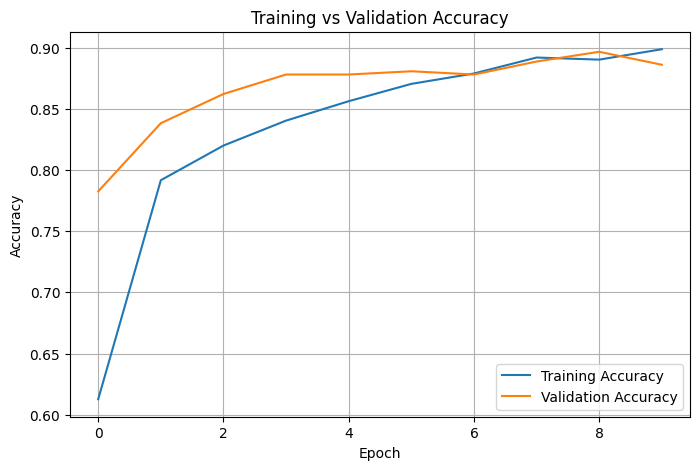

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_v2.history["accuracy"], label="Training Accuracy")
plt.plot(history_v2.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

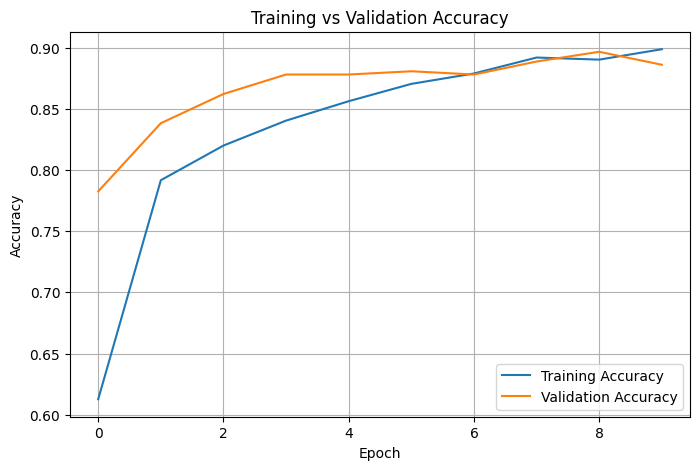

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_v2.history["accuracy"], label="Training Accuracy")
plt.plot(history_v2.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

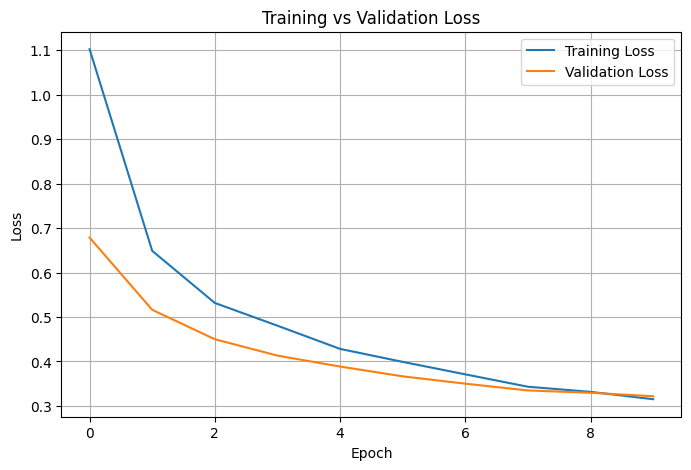

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

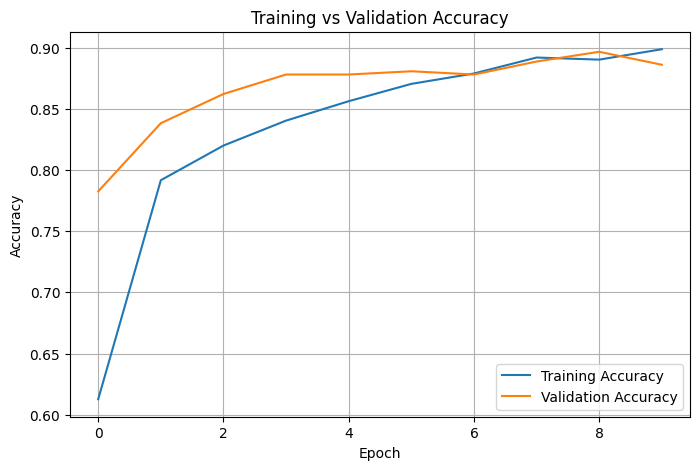

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["accuracy"], label="Training Accuracy")
plt.plot(history_v2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

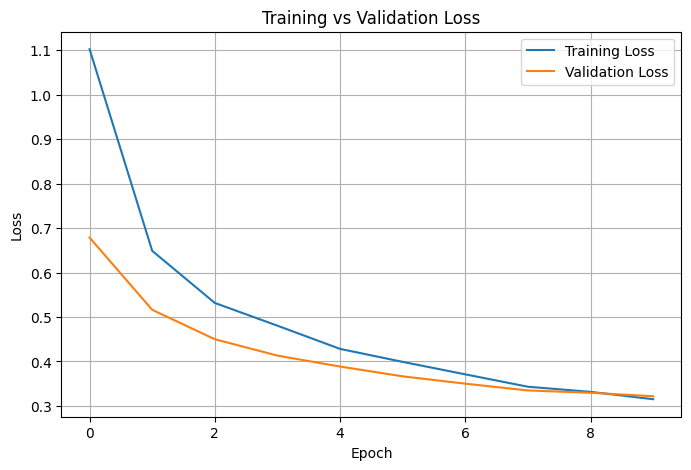

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("Version 2 Test Accuracy:", test_accuracy_v2)
print("Version 2 Test Loss:", test_loss_v2)

12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.8646 - loss: 0.3687
Version 2 Test Accuracy: 0.8645833134651184
Version 2 Test Loss: 0.3687296211719513


In [42]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-07 180233.png to Screenshot 2026-09-07 180233.png


In [43]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Class names
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Load image
img = load_img(
    "Screenshot 2026-09-07 180233.png",
    target_size=(224, 224)
)

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model_v2.predict(img_array)

# Find the class with highest probability
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Predicted Waste:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Waste: paper
Confidence: 88.56 %
